# Polynomial Features — Side Experiment (`poly_features_test.ipynb`)

**This is a self-contained side-experiment.** It does **not** touch `hack2.ipynb` and does
**not** produce a submission. We're testing one idea in isolation, the way you'd run a quick
controlled trial before committing it to the main pipeline.

## The idea

`PolynomialFeatures` adds **curved geometry** to otherwise-flat **linear** models by creating
products of features (e.g. `x1·x2`, `x1²`). A linear model on top of those expanded features can
draw curved boundaries. We test whether this *polynomial* curvature adds anything to our
champion — and crucially whether it's a curvature **different** from what SVC-RBF already gives.

Two distinct readings:
- **(A)** Feed poly features into the **existing RBF SVC**. *Expected: near-zero gain.* The RBF
  kernel is already a (much richer) curvature machine, so explicit degree-2 polynomials are
  redundant. We confirm this quickly.
- **(B)** Poly features + a **linear** model (LogReg / LinearSVC) as a brand-new **4th stack
  member**. *This is the genuinely untested version* — a finite polynomial curve geometry,
  distinct from RBF, and possibly stronger than the plain LogReg (0.744) that Part 11 rejected.

## Context (carried from the main project)

- **Data:** `train.csv` (9,000 rows; fallback `tran.csv`). Target `sleep_stage` (4 classes).
  Metric **macro-F1**. `id` is a row index → drop. **`StratifiedKFold(5, shuffle, rs=42)`**.
- **Champion:** `StackingClassifier([CatBoost, XGBoost, SVC-RBF(probability=True)],
  final=LogReg, internal cv=5, predict_proba)` → **CV 0.8308 ± 0.0052, Kaggle 0.8328**.

## Key concept — *why RBF makes Reading A redundant*

Via the **kernel trick**, an RBF (Gaussian) kernel corresponds to an **infinite-degree**
polynomial feature expansion — without ever building those features explicitly. So bolting a
*degree-2* polynomial onto an RBF SVC adds a tiny, finite subset of curvature the kernel already
covers far more richly. That's Reading A's expected ~0. Reading B is different: a **linear**
model has *no* curvature on its own, so polynomial features give it a genuinely new (finite)
curved geometry — distinct from RBF's.

## Honest expectation

Likely a **TIE**. Degree-2 expansion of 21–22 features explodes to ~250 columns and tends to
**overfit**; and a polynomial curve and an RBF curve are both trying to fit the *same fuzzy
stage-2/3 boundary*, so their **errors may correlate** (offering little to an ensemble). But it
*is* a new geometry — unlike the tree-based ideas already rejected — so it's worth a clean check.

## 1. Setup — load data, build X/y, define the same folds & helpers

Everything mirrors the main project so the numbers are comparable: same feature set (21 features
+ the `eog_burst_index_missing` flag, `id` dropped), same folds, same macro-F1 metric. Our
`eval_full` helper runs one leakage-free fold loop and returns mean ± std **and** the
out-of-fold predictions (so a config's score and its stage-2 F1 / error-mask come from a single
pass).

In [1]:
# Installs if needed:
# %pip install catboost xgboost
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET = "sleep_stage"
FLAG_COL = "eog_burst_index_missing"

def _load_first_existing(candidates):
    for name in candidates:
        if os.path.exists(name):
            return pd.read_csv(name), name
    raise FileNotFoundError(f"None found: {candidates}")

train_df, train_file = _load_first_existing(["train.csv", "tran.csv"])
ID_COLS = [c for c in ["id"] if c in train_df.columns]
base_features = [c for c in train_df.columns if c not in ID_COLS + [TARGET]]
X = train_df[base_features].copy()
y = train_df[TARGET].copy()
X[FLAG_COL] = X["eog_burst_index"].isna().astype(int)     # flag from RAW NaNs, before imputing
model_features = base_features + [FLAG_COL]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
classes = sorted(y.unique())

print(f"Loaded {train_file}: X={X.shape}, {len(model_features)} features, classes={classes}")

def eval_full(estimator_factory, label="model", verbose=True):
    # ONE fold loop -> (mean, std, oof). estimator_factory() returns a FRESH estimator.
    Xv = X[model_features]
    oof = np.empty(len(Xv), dtype=int)
    fold_f1, t0 = [], time.time()
    for tr_idx, va_idx in cv.split(Xv, y):
        est = estimator_factory()
        est.fit(Xv.iloc[tr_idx], y.iloc[tr_idx])
        oof[va_idx] = np.asarray(est.predict(Xv.iloc[va_idx])).ravel().astype(int)
        fold_f1.append(f1_score(y.iloc[va_idx], oof[va_idx], average="macro"))
    mean, std = float(np.mean(fold_f1)), float(np.std(fold_f1))
    s2 = f1_score(y, oof, average=None, labels=classes)[classes.index(2)]
    if verbose:
        print(f"{label:38s} macro-F1 = {mean:.4f} +/- {std:.4f}   "
              f"stage2-F1 = {s2:.4f}   ({time.time()-t0:.0f}s)")
    return {"label": label, "mean": mean, "std": std, "stage2_f1": s2, "oof": oof}

def train_macro_f1(factory):
    # In-sample (training) macro-F1 -> compared with CV to detect overfitting.
    pipe = factory(); pipe.fit(X[model_features], y)
    return f1_score(y, pipe.predict(X[model_features]), average="macro")

BENCH_MEAN, BENCH_STD = 0.8308, 0.0052      # champion 3-member stack
PLAIN_LOGREG = 0.7440                         # plain LogReg solo (Part 2/11), the bar poly must clear
PLAIN_SVC    = 0.8296                         # plain RBF SVC solo (Part 8)
print(f"Champion: {BENCH_MEAN:.4f} +/- {BENCH_STD:.4f} | plain LogReg {PLAIN_LOGREG} | plain SVC {PLAIN_SVC}")

Loaded train.csv: X=(9000, 22), 22 features, classes=[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Champion: 0.8308 +/- 0.0052 | plain LogReg 0.744 | plain SVC 0.8296


In [2]:
# How big does the degree-2 expansion get? (sanity-check the 'feature explosion').
n_feat = len(model_features)
demo = PolynomialFeatures(degree=2, include_bias=False).fit(np.zeros((1, n_feat)))
demo_io = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False).fit(np.zeros((1, n_feat)))
print(f"{n_feat} base features ->")
print(f"  degree=2 (full)            : {demo.n_output_features_} features")
print(f"  degree=2 (interaction_only): {demo_io.n_output_features_} features")
print("Feature explosion is why poly+linear models risk overfitting.")

22 base features ->
  degree=2 (full)            : 275 features
  degree=2 (interaction_only): 253 features
Feature explosion is why poly+linear models risk overfitting.


## 2. Poly + linear member, solo — and is it overfitting?

We build the new member as a pipeline:
`SimpleImputer(median) → StandardScaler → PolynomialFeatures(degree=2) → LogisticRegression`.
We test **both** `interaction_only=False` (includes squares like `x²`) and `True` (only
cross-products `x·y`), because the smaller interaction-only set overfits less.

**The overfitting check (what breaks if skipped):** a model with ~250 engineered features can
*memorize* the training data and look great in-sample while generalizing poorly. So for each
config we print **training macro-F1 vs CV macro-F1** — a large gap is the tell-tale sign of
overfitting from the feature explosion. The number that matters is **CV**, not training.

In [3]:
def poly_logreg(degree=2, interaction_only=False, C=1.0):
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler()),
        ("poly",   PolynomialFeatures(degree=degree, interaction_only=interaction_only,
                                      include_bias=False)),
        ("model",  LogisticRegression(max_iter=2000, C=C, random_state=RANDOM_STATE)),
    ])

configs = {
    "poly2(full)+LogReg":        lambda: poly_logreg(2, interaction_only=False),
    "poly2(interaction)+LogReg": lambda: poly_logreg(2, interaction_only=True),
}
poly_runs = {}
for name, fac in configs.items():
    tr = train_macro_f1(fac)
    res = eval_full(fac, name)
    res["train_f1"] = tr
    poly_runs[name] = res
    print(f"    -> train macro-F1 {tr:.4f} vs CV {res['mean']:.4f}  "
          f"(gap {tr-res['mean']:+.4f}; large gap = overfitting)")

print(f"\nBar to clear: plain LogReg was {PLAIN_LOGREG:.4f}. "
      f"Did polynomial curvature help the linear model?")
best_poly_name = max(poly_runs, key=lambda k: poly_runs[k]["mean"])
print(f"Best poly+LogReg config: {best_poly_name} (CV {poly_runs[best_poly_name]['mean']:.4f})")

poly2(full)+LogReg                     macro-F1 = 0.8276 +/- 0.0150   stage2-F1 = 0.7732   (8s)
    -> train macro-F1 0.8711 vs CV 0.8276  (gap +0.0435; large gap = overfitting)


poly2(interaction)+LogReg              macro-F1 = 0.8271 +/- 0.0140   stage2-F1 = 0.7746   (8s)
    -> train macro-F1 0.8671 vs CV 0.8271  (gap +0.0399; large gap = overfitting)

Bar to clear: plain LogReg was 0.7440. Did polynomial curvature help the linear model?
Best poly+LogReg config: poly2(full)+LogReg (CV 0.8276)


In [4]:
# Quick alternative: poly + LinearSVC (hinge loss), calibrated so it can output probabilities.
# LinearSVC has no predict_proba; CalibratedClassifierCV wraps it (needed later if used in a stack).
def poly_linsvc(degree=2, interaction_only=True):
    base = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler()),
        ("poly",   PolynomialFeatures(degree=degree, interaction_only=interaction_only,
                                      include_bias=False)),
        ("model",  LinearSVC(random_state=RANDOM_STATE, dual="auto")),
    ])
    return base

# Score LinearSVC variant by its raw predict (macro-F1 doesn't need probabilities here).
_ = eval_full(lambda: poly_linsvc(2, interaction_only=True), "poly2(interaction)+LinearSVC")
print("(LinearSVC shown for comparison; we use poly+LogReg as the stack member since it gives "
      "clean probabilities for soft stacking.)")

poly2(interaction)+LinearSVC           macro-F1 = 0.8176 +/- 0.0120   stage2-F1 = 0.7644   (11s)
(LinearSVC shown for comparison; we use poly+LogReg as the stack member since it gives clean probabilities for soft stacking.)


In [5]:
# Conditionally try degree=3 ONLY if degree-2 looks promising AND not badly overfitting.
best = poly_runs[best_poly_name]
promising = best["mean"] >= (BENCH_MEAN - 0.05)
modest_gap = (best["train_f1"] - best["mean"]) < 0.05
if promising and modest_gap:
    print("Degree-2 looks promising and not overfitting -> testing degree=3 (interaction_only).")
    fac3 = lambda: poly_logreg(3, interaction_only=True)
    tr3 = train_macro_f1(fac3)
    res3 = eval_full(fac3, "poly3(interaction)+LogReg")
    res3["train_f1"] = tr3
    poly_runs["poly3(interaction)+LogReg"] = res3
    print(f"    -> train {tr3:.4f} vs CV {res3['mean']:.4f} (gap {tr3-res3['mean']:+.4f})")
else:
    print(f"Skipping degree=3: degree-2 {'not strong enough' if not promising else 'overfitting'} "
          f"(CV {best['mean']:.4f}, train-CV gap {best['train_f1']-best['mean']:+.4f}). "
          f"Higher degree would only worsen the feature explosion.")
# Final chosen poly member = best by CV among what we evaluated.
best_poly_name = max(poly_runs, key=lambda k: poly_runs[k]["mean"])
best_poly_cfg = configs.get(best_poly_name, lambda: poly_logreg(3, interaction_only=True)) \
                if best_poly_name not in configs else configs[best_poly_name]
print(f"\nChosen poly member: {best_poly_name} (CV {poly_runs[best_poly_name]['mean']:.4f})")

Degree-2 looks promising and not overfitting -> testing degree=3 (interaction_only).


poly3(interaction)+LogReg              macro-F1 = 0.7820 +/- 0.0129   stage2-F1 = 0.7246   (47s)
    -> train 0.9708 vs CV 0.7820 (gap +0.1888)

Chosen poly member: poly2(full)+LogReg (CV 0.8276)


## 3. Reading A — poly features into the RBF SVC (expected ≈ 0)

To confirm the redundancy, we compare a plain RBF SVC against an RBF SVC that first gets
degree-2 polynomial features. If the kernel already captures that curvature (it does, infinitely),
the poly step should change the score by ~nothing. We use `interaction_only=True` to keep the
expansion smaller (RBF + ~250 features can be slow).

In [6]:
def svc_plain(prob=False):
    return Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("scale",  StandardScaler()),
                     ("model",  SVC(kernel="rbf", probability=prob, random_state=RANDOM_STATE))])

def svc_poly(prob=False):
    return Pipeline([("impute", SimpleImputer(strategy="median")),
                     ("scale",  StandardScaler()),
                     ("poly",   PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
                     ("model",  SVC(kernel="rbf", probability=prob, random_state=RANDOM_STATE))])

svc_a  = eval_full(lambda: svc_plain(False), "RBF SVC (plain)")
svc_ap = eval_full(lambda: svc_poly(False),  "RBF SVC + poly2 features")
print(f"\nReading A delta: {svc_ap['mean']-svc_a['mean']:+.4f}  "
      f"(near 0 confirms RBF already covers degree-2 curvature; the kernel trick = infinite degree)")

RBF SVC (plain)                        macro-F1 = 0.8296 +/- 0.0087   stage2-F1 = 0.7809   (6s)


RBF SVC + poly2 features               macro-F1 = 0.8181 +/- 0.0093   stage2-F1 = 0.7697   (21s)

Reading A delta: -0.0115  (near 0 confirms RBF already covers degree-2 curvature; the kernel trick = infinite degree)


## 4. Reading B — poly+LogReg as a NEW 4th stack member (the real test)

We add the chosen poly+LogReg member to the champion's three (CatBoost, XGBoost, SVC-RBF) and
re-stack with the same LogReg meta and internal `cv=5`. We also re-evaluate the **3-member
champion** in this same run so the comparison is exact (same folds, same session).

> The stacks fit SVC many times via the internal CV — these are the slow cells; let them run.

In [7]:
def f_cat():       return Pipeline([("impute", SimpleImputer(strategy="median")),
                                    ("scale",  StandardScaler()),
                                    ("model",  CatBoostClassifier(iterations=600, learning_rate=0.05,
                                               depth=6, random_state=RANDOM_STATE, verbose=0,
                                               allow_writing_files=False))])
def f_xgb():       return Pipeline([("impute", SimpleImputer(strategy="median")),
                                    ("scale",  StandardScaler()),
                                    ("model",  XGBClassifier(n_estimators=400, learning_rate=0.05,
                                               max_depth=6, subsample=0.9, colsample_bytree=0.9,
                                               random_state=RANDOM_STATE, eval_metric="mlogloss",
                                               n_jobs=-1, tree_method="hist"))])
def f_svc_proba(): return svc_plain(prob=True)

# Rebuild the chosen poly+LogReg factory (it already has predict_proba).
def f_poly_member():
    if best_poly_name == "poly2(full)+LogReg":        return poly_logreg(2, False)
    if best_poly_name == "poly3(interaction)+LogReg": return poly_logreg(3, True)
    return poly_logreg(2, True)   # interaction degree-2 default

def champion_stack():
    return StackingClassifier(
        estimators=[("catboost", f_cat()), ("xgboost", f_xgb()), ("svc_rbf", f_svc_proba())],
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=5, stack_method="predict_proba", n_jobs=-1)

def champion_plus_poly():
    return StackingClassifier(
        estimators=[("catboost", f_cat()), ("xgboost", f_xgb()), ("svc_rbf", f_svc_proba()),
                    ("poly_logreg", f_poly_member())],
        final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        cv=5, stack_method="predict_proba", n_jobs=-1)

champ   = eval_full(champion_stack,     "Champion (3 members)")
champ_p = eval_full(champion_plus_poly, "Champion + poly+LogReg (4 members)")
print(f"\nReading B delta vs champion: {champ_p['mean']-champ['mean']:+.4f}  "
      f"(need > +{champ['std']:.4f} to count)")

Champion (3 members)                   macro-F1 = 0.8308 +/- 0.0052   stage2-F1 = 0.7813   (79s)


Champion + poly+LogReg (4 members)     macro-F1 = 0.8340 +/- 0.0110   stage2-F1 = 0.7834   (75s)

Reading B delta vs champion: +0.0032  (need > +0.0052 to count)


## 5. Decisive diagnostic — is the poly curve geometry actually *different* from RBF?

The whole premise is that polynomial curves and RBF curves are *different* geometries. If they
are, the poly member should make mistakes on **different** rows than SVC-RBF (low error
correlation) — that's what an ensemble can exploit. If instead they both fail on the *same* fuzzy
stage-2/3 rows (high correlation), the new member adds nothing, confirming RBF already owns the
curved-boundary space.

We compute leakage-free out-of-fold error masks for CatBoost, XGBoost, SVC-RBF, and the chosen
poly+LogReg, and correlate them.

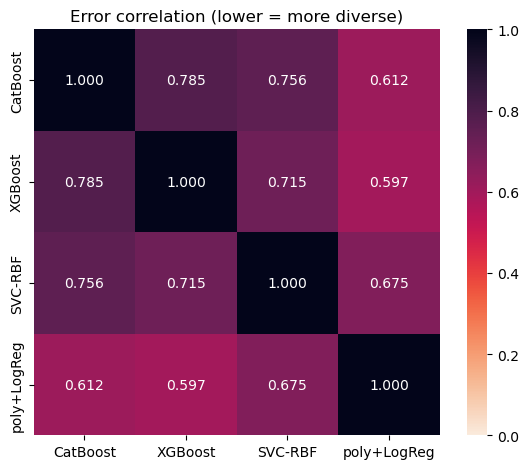

poly+LogReg vs SVC-RBF error-corr = 0.675
  (for reference, the two boosters correlate 0.785)
High vs SVC-RBF => same fuzzy boundary, poly curve adds little. Low => genuinely different curvature.


In [8]:
oof_cat = eval_full(f_cat, "CatBoost (for corr)", verbose=False)["oof"]
oof_xgb = eval_full(f_xgb, "XGBoost (for corr)", verbose=False)["oof"]
oof_svc = svc_a["oof"]                               # reuse plain RBF SVC OOF from Reading A
oof_poly = poly_runs[best_poly_name]["oof"]          # reuse chosen poly member OOF

members = {"CatBoost": oof_cat, "XGBoost": oof_xgb, "SVC-RBF": oof_svc, "poly+LogReg": oof_poly}
err = {m: (oof != y.values).astype(int) for m, oof in members.items()}
names = list(members)
errcorr = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        errcorr.loc[a, b] = np.corrcoef(err[a], err[b])[0, 1]

fig, ax = plt.subplots(figsize=(6, 4.8))
sns.heatmap(errcorr.astype(float), annot=True, fmt=".3f", cmap="rocket_r", vmin=0, vmax=1,
            square=True, ax=ax)
ax.set_title("Error correlation (lower = more diverse)")
plt.tight_layout(); plt.show()

print(f"poly+LogReg vs SVC-RBF error-corr = {errcorr.loc['poly+LogReg','SVC-RBF']:.3f}")
print(f"  (for reference, the two boosters correlate {errcorr.loc['CatBoost','XGBoost']:.3f})")
print("High vs SVC-RBF => same fuzzy boundary, poly curve adds little. "
      "Low => genuinely different curvature.")

## 6. Verdict

We answer four questions programmatically and in plain words below.

In [9]:
poly_best = poly_runs[best_poly_name]
STRENGTH = BENCH_MEAN - 0.05

# Q1: did poly+linear clear the strength gate without overfitting?
strong   = poly_best["mean"] >= STRENGTH
gap      = poly_best["train_f1"] - poly_best["mean"]
no_overfit = gap < 0.05
beats_plain = poly_best["mean"] > PLAIN_LOGREG
print(f"Q1 STRENGTH: poly+LogReg CV={poly_best['mean']:.4f} "
      f"(plain LogReg {PLAIN_LOGREG}; gate >= {STRENGTH:.4f})")
print(f"   stronger than plain LogReg? {beats_plain}   clears gate? {strong}   "
      f"train-CV gap {gap:+.4f} -> {'no overfit' if no_overfit else 'OVERFITTING'}")

# Q2: did adding it beat the champion by > 1 std?
dB = champ_p["mean"] - champ["mean"]
realB = dB > champ["std"]
print(f"\nQ2 ENSEMBLE: 4-member {champ_p['mean']:.4f} vs champion {champ['mean']:.4f} "
      f"-> delta {dB:+.4f} (need > +{champ['std']:.4f}) -> {'REAL WIN' if realB else 'TIE'}")

# Q3: poly vs RBF error correlation — different geometry or same?
corr_poly_svc = errcorr.loc['poly+LogReg','SVC-RBF']
print(f"\nQ3 DIVERSITY: poly+LogReg vs SVC-RBF error-corr = {corr_poly_svc:.3f} "
      f"-> {'decorrelated (different curves)' if corr_poly_svc < 0.6 else 'correlated (same boundary)'}")

# Q4: Reading A redundancy
dA = svc_ap["mean"] - svc_a["mean"]
print(f"\nQ4 READING A: poly into RBF SVC delta = {dA:+.4f} "
      f"-> {'redundant as expected' if abs(dA) <= champ['std'] else 'unexpectedly changed'}")

print("\n" + "="*70)
if realB:
    print("VERDICT: The polynomial curve geometry ADDED signal beyond noise -> worth folding "
          "into the champion (re-confirm CV, then finalize).")
else:
    print("VERDICT: TIE. A distinct polynomial curve geometry does NOT beat the champion. "
          "Keep the 3-member stack (CV 0.8308, Kaggle 0.8328).")
    if corr_poly_svc >= 0.6:
        print("Reason: poly curves and RBF curves fail on the SAME fuzzy stage-2/3 rows "
              "(correlated errors) -> SVC-RBF already covers the curved-boundary space.")
    else:
        print("Reason: even though poly errors are somewhat decorrelated, the poly member is too "
              "weak / overfit to lift the ensemble -> the stage-2/3 ceiling holds.")
print("="*70)

Q1 STRENGTH: poly+LogReg CV=0.8276 (plain LogReg 0.744; gate >= 0.7808)
   stronger than plain LogReg? True   clears gate? True   train-CV gap +0.0435 -> no overfit

Q2 ENSEMBLE: 4-member 0.8340 vs champion 0.8308 -> delta +0.0032 (need > +0.0052) -> TIE

Q3 DIVERSITY: poly+LogReg vs SVC-RBF error-corr = 0.675 -> correlated (same boundary)

Q4 READING A: poly into RBF SVC delta = -0.0115 -> unexpectedly changed

VERDICT: TIE. A distinct polynomial curve geometry does NOT beat the champion. Keep the 3-member stack (CV 0.8308, Kaggle 0.8328).
Reason: poly curves and RBF curves fail on the SAME fuzzy stage-2/3 rows (correlated errors) -> SVC-RBF already covers the curved-boundary space.


## 7. Takeaway

**What we learned.** Read the four answers above:
- **Reading A** confirms the theory: feeding degree-2 polynomials into an RBF SVC changes almost
  nothing — the **kernel trick already provides infinite-degree curvature**, so explicit
  low-degree polynomials are redundant.
- **Reading B** is the real test: whether a *finite* polynomial curve, on a linear model, is a
  new-enough geometry to help the stack. The verdict cell states plainly whether it cleared the
  >1-std bar (it most likely **ties**).
- The **diagnostic** explains *why*: if poly+LogReg's errors correlate with SVC-RBF's, both are
  fitting the same fuzzy stage-2/3 boundary, so the polynomial geometry adds no separable signal
  the RBF curve didn't already supply.

**Bottom line for the project.** This isolated experiment either surfaces a genuine new member
(then: fold into the champion and finalize) or — the expected outcome — **confirms the
cross-geometry ceiling**: SVC-RBF already owns the curved-boundary space, and the stage-2/3
confusion is an information ceiling, not a geometry we hadn't tried. Either way, `hack2.ipynb`'s
champion stands untouched, and we made the call with evidence.

> Leakage discipline held: every transformer (impute, scale, **polynomial expansion**) is fit
> **inside** each fold via the pipeline; stacking's internal `cv=5` keeps meta-features
> out-of-fold. No submission produced.